<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Semanal Nº1
#### Lucas Douat

## Introduccion
En esta práctica trabajamos con la síntesis de señales digitales (generación) utilizando Python, abordando aspectos fundamentales del procesamiento de señales como la creación, modificación y análisis de formas de onda. Se generarán señales sinusoidales, cuadradas y pulsos rectangulares, aplicando transformaciones en amplitud, desfases y conceptos de modulación, incluyendo recortes de amplitud.

Para cada señal se indicarán parámetros clave como el tiempo entre muestras, el número total de muestras, y la energía o potencia, según corresponda.

Además, se verificará la ortogonalidad entre señales, lo cual permite evaluar el grado de independencia entre ellas. Este análisis se realizará mediante el producto interno entre dos señales discretas:

$$ \langle x, y \rangle = \sum_{k=1}^{N} x[k]\cdot y[k] $$

También se estudiará la autocorrelación de una señal y su correlación cruzada con el resto de las señales generadas, lo que permitirá analizar similitudes temporales y relaciones entre las formas de onda trabajadas.

##Analisís y Desarrollo

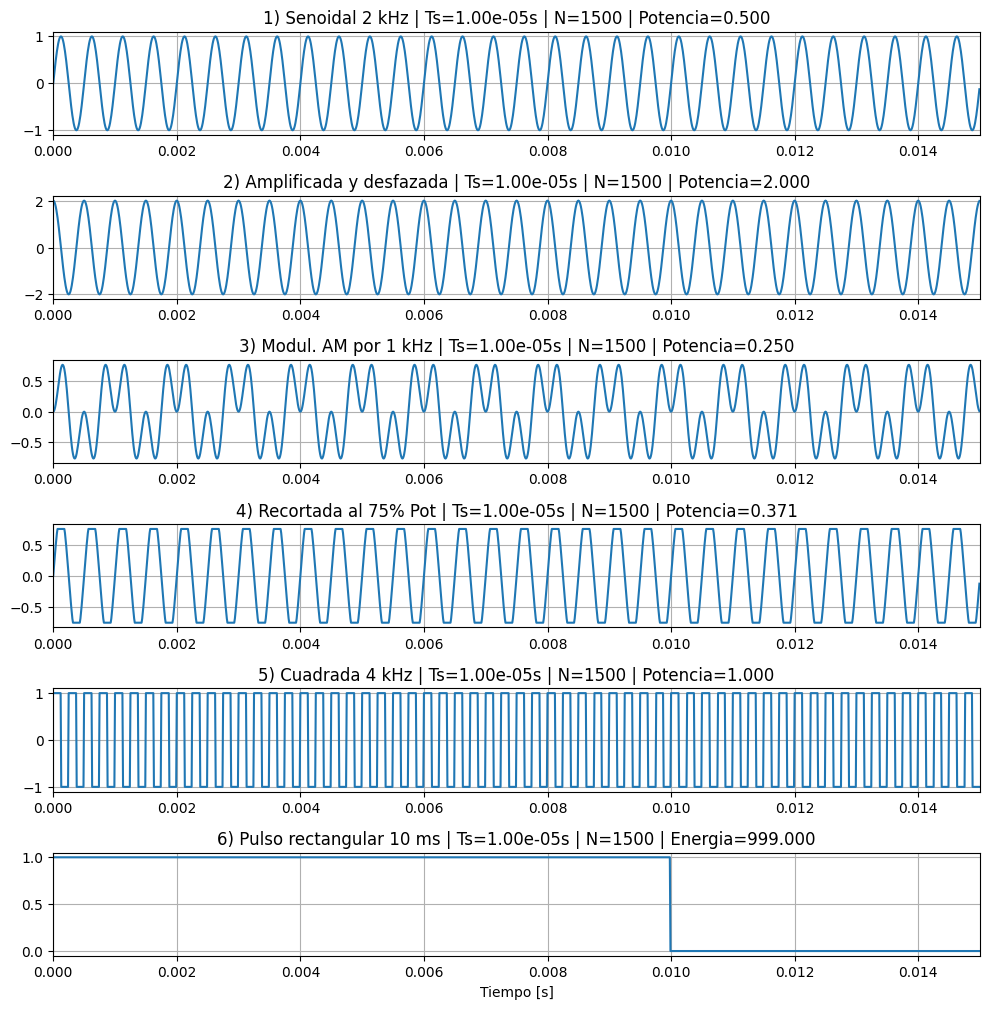

In [3]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on ...

@author: Lucas Douat

Descripción:
------------
Tarea Semanal N°1 - Síntesis de señales
"""

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.signal import square

#%%  Definicion de Funciones
def signal_pot(x):
    return np.mean(x**2)
    
def signal_energy(x):
    return np.sum(x**2)
    
#%% 1) Sintetizar y graficar:
fs = 100000  # frecuencia de muestreo en Hz
Ts = 1 / fs  # tiempo entre muestras
N = 1500     # número de muestras
tt = np.linspace(0, (N-1)*Ts, N).flatten() # vector de tiempo
"""
fs: frecuencia de muestreo 100 kHz.
Ts: tiempo entre muestras, calculado como el inverso de fs.
N: cantidad total de muestras.
tt: vector de tiempo, desde 0 hasta (N-1)*Ts.
"""
#Señal 1: Senoidal de 2 kHz
f1 = 2000
x1 = np.sin(2 * np.pi * f1 * tt)


#Señal 2: Amplificada y desfazada
x2 = 2 * np.sin(2 * np.pi * f1 * tt + np.pi/2)
"""
Misma señal que x1, pero:
amplitud duplicada (×2)
fase desplazada en pi/2 radianes
"""

#Señal 3: Modulada en amplitud
f_mod = 1000
modulador = np.sin(2 * np.pi * f_mod * tt)
x3 = x1 * modulador

"""Se genera una señal senoidal de 1 kHz (modulador)
Se usa como envolvente para modular la amplitud de x1
Esto simula una modulación AM (amplitud modulada)"""

#Señal 4: Recortada al 75% de la amplitud
x4 = np.clip(x1, -0.75,0.75)

# Señal 5: Cuadrada de 4 kHz
f5 = 4000
x5 = square(2 * np.pi * f5 * tt)


# Señal 6: Pulso rectangular de 10 ms
N_pulso = int(0.01/Ts)
x6 = np.zeros(N)
x6[:N_pulso] = 1

# Graficar todas las señales
fig, axs = plt.subplots(6, 1, figsize=(10, 10))
axs[0].plot(tt, x1)
axs[0].set_title(f"1) Senoidal 2 kHz | Ts={Ts:.2e}s | N={N} | Potencia={signal_pot(x1):.3f}")

axs[1].plot(tt, x2)
axs[1].set_title(f"2) Amplificada y desfazada | Ts={Ts:.2e}s | N={N} | Potencia={signal_pot(x2):.3f}")

axs[2].plot(tt, x3)
axs[2].set_title(f"3) Modul. AM por 1 kHz | Ts={Ts:.2e}s | N={N} | Potencia={signal_pot(x3):.3f}")

axs[3].plot(tt, x4)
axs[3].set_title(f"4) Recortada al 75% Pot | Ts={Ts:.2e}s | N={N} | Potencia={signal_pot(x4):.3f}")

axs[4].plot(tt, x5)
axs[4].set_title(f"5) Cuadrada 4 kHz | Ts={Ts:.2e}s | N={N} | Potencia={signal_pot(x5):.3f}")

axs[5].plot(tt, x6)
axs[5].set_title(f"6) Pulso rectangular 10 ms | Ts={Ts:.2e}s | N={N} | Energia={signal_energy(x6):.3f}")

for ax in axs:
    ax.set_xlim([0, N*Ts])
    ax.grid(True)

plt.tight_layout()
plt.xlabel("Tiempo [s]")
plt.show()


## Potencia y Energía 

Para hablar de energía debemos tener en cuenta si nuestra señal es de duración finita, como en el caso del pulso rectangular de 10 ms (x6). En estos casos, se analiza la energía total, que se calcula como:
$$E = \sum_{k=1}^{N} |x[k]|^2$$
En cambio, si la señal es periódica o de duración infinita (como las senoidales, la señal cuadrada o la señal modulada), se analiza la potencia promedio, definida como:
$$P = \frac{1}{N} \sum_{k=1}^{N} |x[k]|^2$$

Es importante aclarar que, en la práctica, trabajamos con una cantidad finita de muestras, por lo tanto podemos calcular ambas métricas sobre el mismo conjunto de datos. Sin embargo, es fundamental tener en cuenta la naturaleza de la señal para interpretar correctamente si corresponde hablar de potencia o energía.

## Conclusión

A lo largo del desarrollo se logró:





## Autoevaluación de Aprendizaje